Particles Time

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap

In [2]:
mask = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')

In [3]:
def finder2(target_lat, target_lon, mask=mask):
    lat = mask.nav_lat
    lon = mask.nav_lon
    distance = ((lat - target_lat)**2 + (lon - target_lon)**2)**0.5
    nearest_index = distance.argmin()
    return int(nearest_index // lon.shape[1]), int(nearest_index % lon.shape[1])

In [4]:
filename = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Simulation_V4_year_1.nc'
ds = xr.open_dataset(filename)

In [5]:
def residence_time_grid(
    lons, lats, dt, mask=mask, num_lon=100, num_lat=100
):
#
    nav_lon = mask['nav_lon'].values
    nav_lat = mask['nav_lat'].values

    # Define edges and centers
    lon_edges = np.linspace(nav_lon.min(), nav_lon.max(), num_lon + 1)
    lat_edges = np.linspace(nav_lat.min(), nav_lat.max(), num_lat + 1)
    lon_centers = (lon_edges[:-1] + lon_edges[1:]) / 2
    lat_centers = (lat_edges[:-1] + lat_edges[1:]) / 2

    # Create a weight array where every particle observation represents 'dt' time
    # This must be the same shape as lons/lats
    weights = np.full_like(lons, fill_value=dt)

    # Weighted histogram: sums weights (time) instead of counts
    res_time_counts, xedges, yedges = np.histogram2d(
        lons, lats,
        bins=[lon_edges, lat_edges],
        weights=weights
    )

    # Create DataFrame (Transpose to align Lat as Index/Rows and Lon as Columns)
    df_res_time = pd.DataFrame(
        res_time_counts.T,  
        index=lat_centers,
        columns=lon_centers
    )

    # --- Mapping to Model Grid Space (using your original logic) ---
    Xcenters, Ycenters = np.meshgrid(lon_centers, lat_centers)
    flat_lon = Xcenters.ravel()
    flat_lat = Ycenters.ravel()

    ii_sed = np.zeros(flat_lon.size, dtype=int)
    jj_sed = np.zeros(flat_lon.size, dtype=int)

    for k in range(flat_lon.size):
        # Using your finder2 function to map centers to model indices
        jj, ii = finder2(flat_lat[k], flat_lon[k], mask)
        ii_sed[k] = ii
        jj_sed[k] = jj

    ii_sed = ii_sed.reshape(Xcenters.shape)
    jj_sed = jj_sed.reshape(Ycenters.shape)
    
    grid_indices = (ii_sed, jj_sed)
    raw_hist = (res_time_counts, xedges, yedges)

    return df_res_time, raw_hist, grid_indices

In [6]:
lons_flat = ds['lon'].values.flatten()
lats_flat = ds['lat'].values.flatten()

In [7]:
valid_idx = ~np.isnan(lons_flat)
lons_clean = lons_flat[valid_idx]
lats_clean = lats_flat[valid_idx]

# 3. Run the function
df_res, raw, indices = residence_time_grid(lons_clean, lats_clean, dt=0.125)

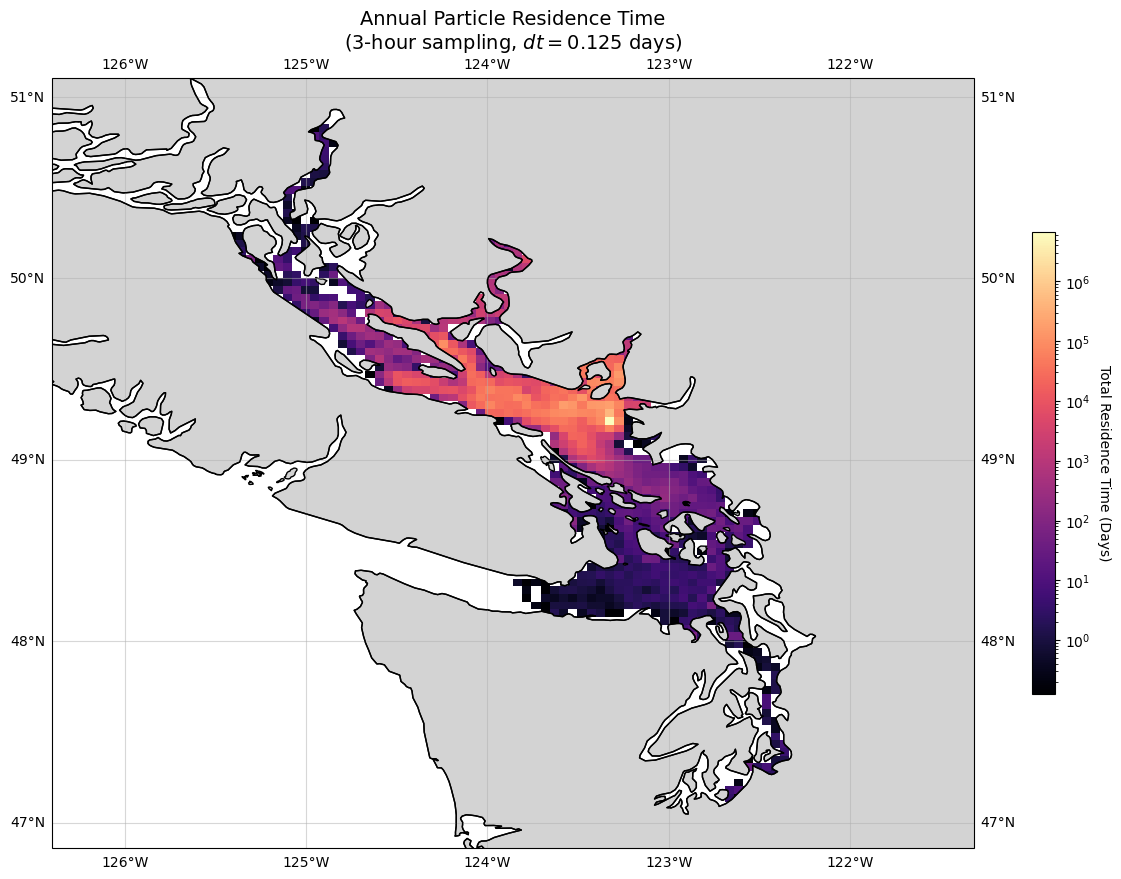

In [8]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm

# Setup the figure
fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, zorder=2, edgecolor='black', facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE, zorder=3)
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, alpha=0.5)

# Extract histogram components
# raw_hist[0] is the 2D array of time values
# raw_hist[1] and [2] are the lon/lat edges
data = raw[0].T  # Transpose to match (lat, lon) plotting convention
lon_edges = raw[1]
lat_edges = raw[2]

# Plotting with LogNorm is crucial for residence time
# It prevents a few high-retention cells from washing out the rest of the map
im = ax.pcolormesh(lon_edges, lat_edges, data, 
                   transform=ccrs.PlateCarree(),
                   norm=LogNorm(vmin=0.125, vmax=data.max()), 
                   cmap='magma', 
                   shading='flat')

# Add Colorbar
cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.05, shrink=0.6)
cbar.set_label('Total Residence Time (Days)', rotation=270, labelpad=15)

plt.title(f'Annual Particle Residence Time\n(3-hour sampling, $dt={0.125}$ days)', fontsize=14)
plt.show()

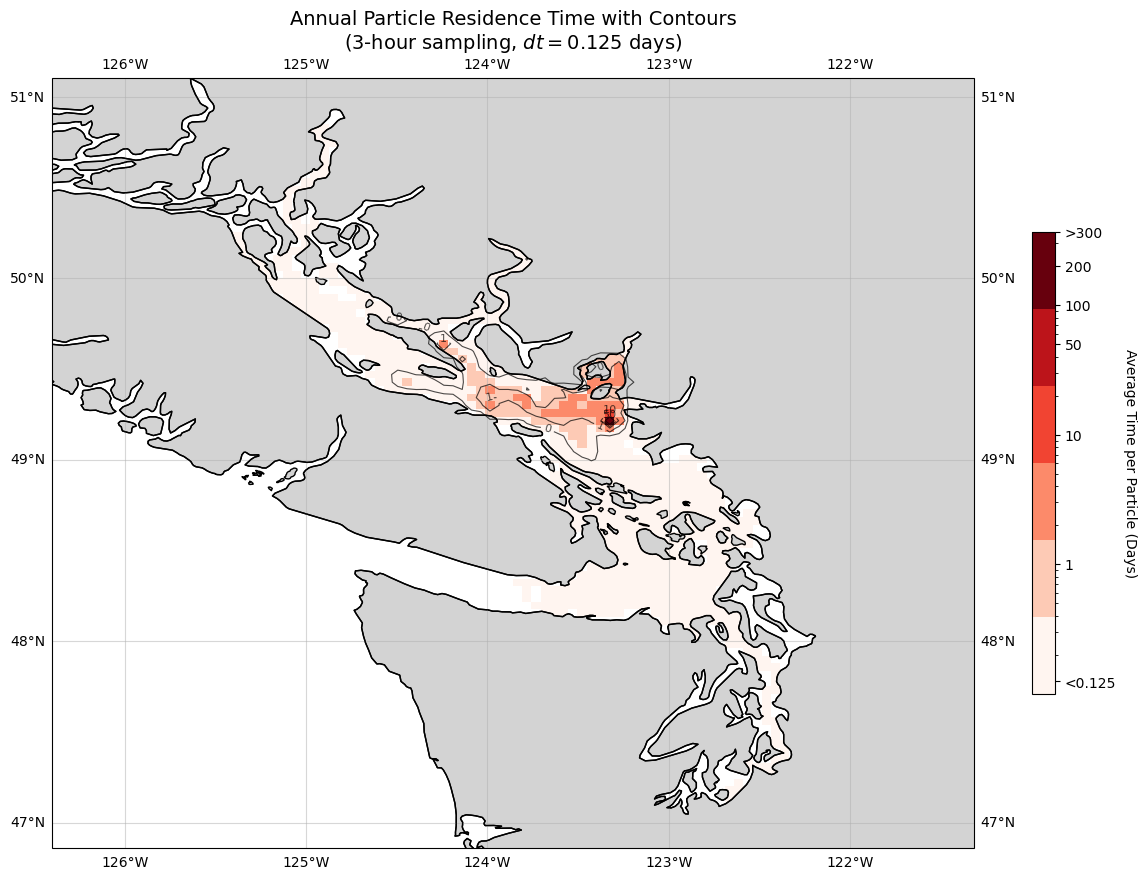

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm
from matplotlib.ticker import FixedLocator, FixedFormatter

# Setup the figure
fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, zorder=2, edgecolor='black', facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE, zorder=3)
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, alpha=0.5)

# Extract histogram components
data = raw[0].T  
lon_edges = raw[1]
lat_edges = raw[2]

data_normalized = data / 35040

# Define your color ranges / contour levels
custom_ticks = [0.125, 1, 10, 50, 100, 200, 365]

# Plot using LogNorm AND the discrete colormap
discrete_cmap = plt.get_cmap('Reds', len(custom_ticks) - 1)
im = ax.pcolormesh(lon_edges, lat_edges, data_normalized, 
                   transform=ccrs.PlateCarree(),
                   norm=LogNorm(vmin=0.1, vmax=365), 
                   cmap=discrete_cmap, 
                   shading='flat')

# --- ADDING CONTOURS ---
# Calculate the center of each bin for the contour function
lon_centers = (lon_edges[:-1] + lon_edges[1:]) / 2
lat_centers = (lat_edges[:-1] + lat_edges[1:]) / 2

# Draw the contour lines matching the custom_ticks exactly
# We use white with a slight transparency so it doesn't overpower the map
contours = ax.contour(lon_centers, lat_centers, data_normalized, 
                      levels=custom_ticks, 
                      colors='k', 
                      linewidths=0.8, 
                      alpha=0.7,
                      transform=ccrs.PlateCarree())

# Optional but recommended: Add tiny text labels to the contour lines themselves
ax.clabel(contours, inline=True, fontsize=8, fmt='%1.0f')

# --- COLORBAR SETUP ---
cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.05, shrink=0.6)
cbar.locator = FixedLocator(custom_ticks)
cbar.formatter = FixedFormatter(['<0.125', '1', '10', '50', '100', '200', '>300'])
cbar.update_ticks()
cbar.set_label('Average Time per Particle (Days)', rotation=270, labelpad=15)

plt.title('Annual Particle Residence Time with Contours\n(3-hour sampling, $dt=0.125$ days)', fontsize=14)
plt.show()

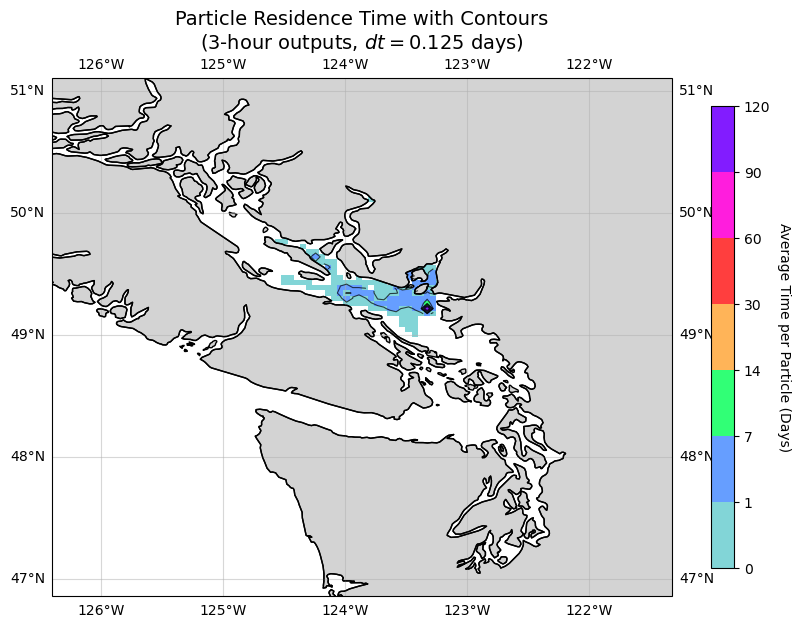

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors  # Needed for BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import FixedLocator, FixedFormatter

# Setup the figure
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, zorder=2, edgecolor='black', facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE, zorder=3)
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, alpha=0.5)

# Extract histogram components
data = raw[0].T  
lon_edges = raw[1]
lat_edges = raw[2]

data_normalized = data / 35040

# Mask the data to hide anything below 0.125 days
data_normalized = np.ma.masked_where(data_normalized < 0.125, data_normalized)

# --- UPDATED: Define your exact color ranges / contour levels ---
custom_ticks = [0, 1, 7, 14, 30, 60, 90, 120]

# 2. Define EXACTLY 7 colors for the 7 gaps between those ticks
# You can use standard names ('red', 'blue'), or HEX codes ('#FF0000') for perfect precision
my_colors= ["#82d5d7", "#669eff", "#31ff76", "#ffb458", "#FF3E3E", "#FF1DDD", "#821CFF"]

# 3. Creae your customc
discrete_cmap = mcolors.ListedColormap(my_colors)

# 4. Bind the data boundaries to your custom colors
norm = mcolors.BoundaryNorm(boundaries=custom_ticks, ncolors=discrete_cmap.N)

# Plot using BoundaryNorm
im = ax.pcolormesh(lon_edges, lat_edges, data_normalized, 
                   transform=ccrs.PlateCarree(),
                   norm=norm, 
                   cmap=discrete_cmap, 
                   shading='flat')

# --- ADDING CONTOURS ---
lon_centers = (lon_edges[:-1] + lon_edges[1:]) / 2
lat_centers = (lat_edges[:-1] + lat_edges[1:]) / 2

# Contours drawn at exact boundary levels
contours = ax.contour(lon_centers, lat_centers, data_normalized, 
                      levels=custom_ticks, 
                      colors='k', 
                      linewidths=0.8, 
                      alpha=0.7,
                      transform=ccrs.PlateCarree())

# --- COLORBAR SETUP ---
# CRITICAL: spacing='uniform' makes each color box the same size visually.
cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.05, shrink=0.6, spacing='uniform')

cbar.locator = FixedLocator(custom_ticks)

# --- UPDATED: Match the text labels to your new ticks ---
cbar.formatter = FixedFormatter(['0', '1', '7', '14', '30', '60', '90', '120'])
cbar.update_ticks()
cbar.set_label('Average Time per Particle (Days)', rotation=270, labelpad=15)

plt.title('Particle Residence Time with Contours\n(3-hour outputs, $dt=0.125$ days)', fontsize=14)
plt.show()

Both avg. concentration and avg. residence times in one year

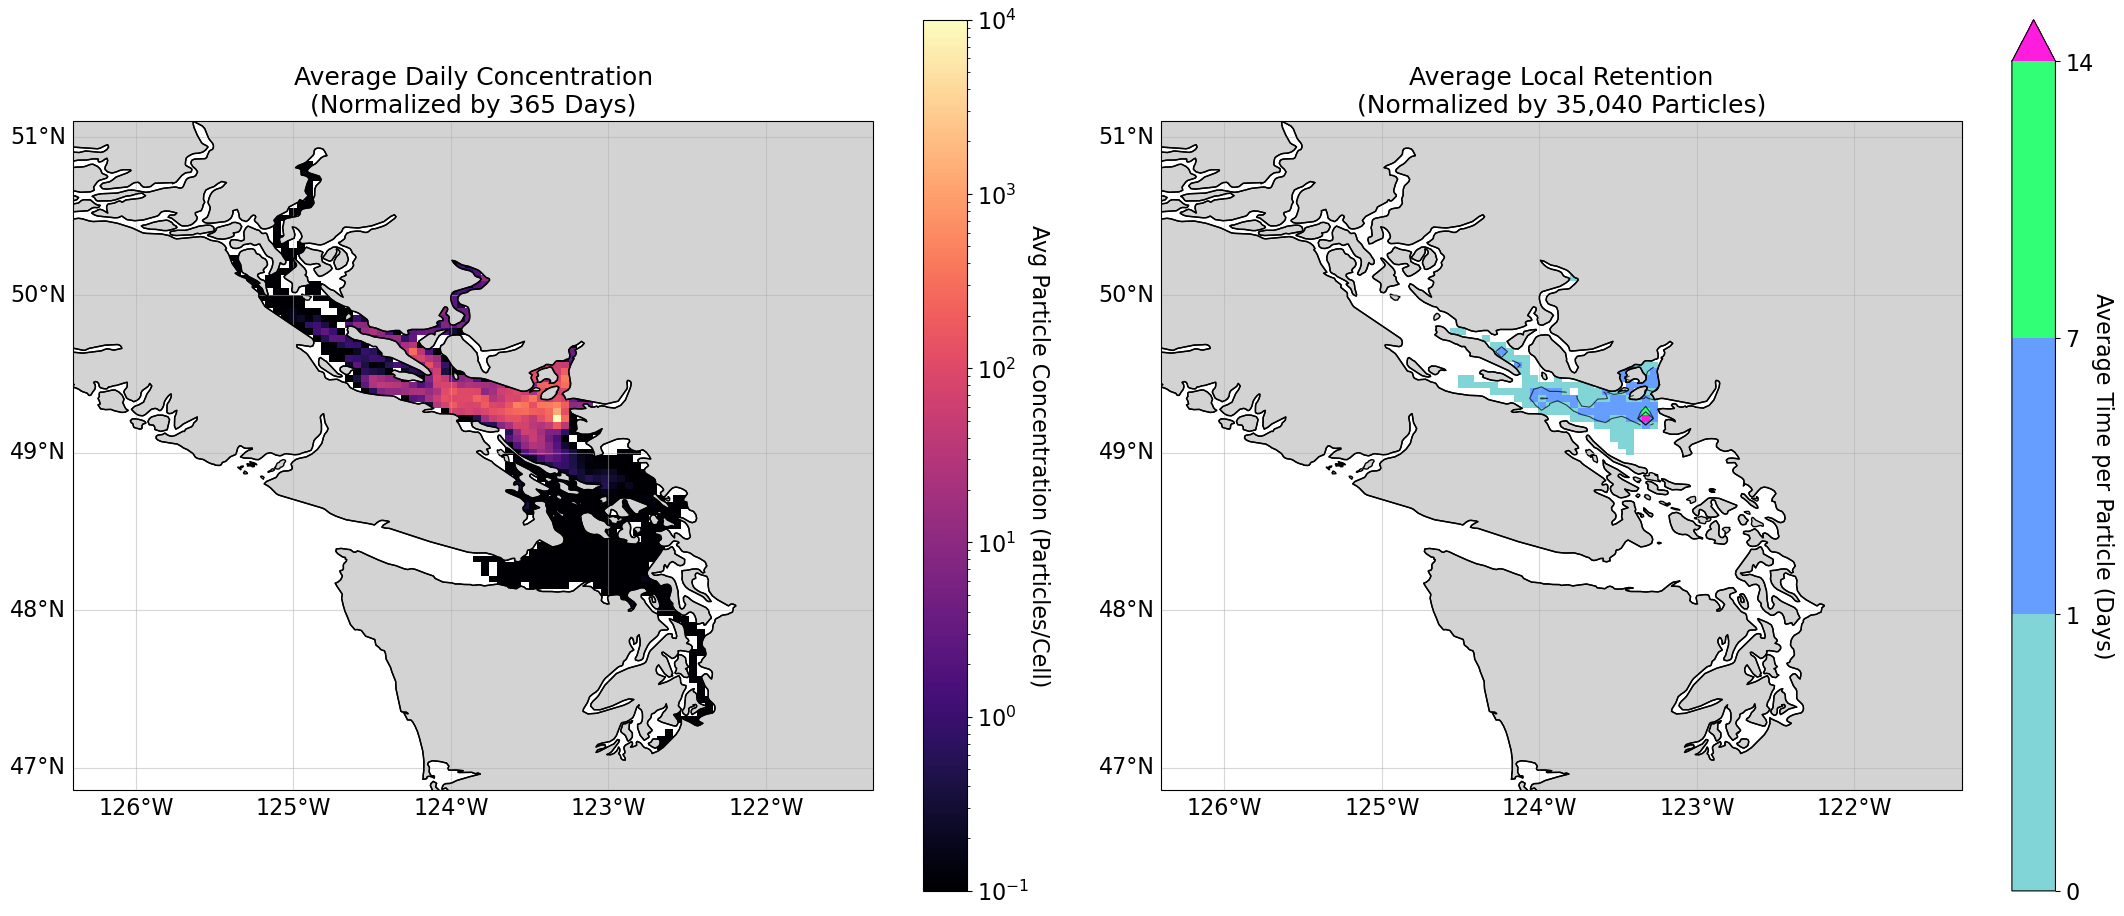

In [11]:
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm
from matplotlib.ticker import FixedLocator, FixedFormatter
plt.rcParams.update({'font.size': 16})# ==========================================
# 1. SETUP FIGURE & EXTRACT DATA
# ==========================================
# Create a wider figure to accommodate two maps side-by-side
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(22, 15), 
                               subplot_kw={'projection': ccrs.PlateCarree()})

# Extract raw histogram components
data = raw[0].T  
lon_edges = raw[1]
lat_edges = raw[2]

# Calculate the centers for the contour lines
lon_centers = (lon_edges[:-1] + lon_edges[1:]) / 2
lat_centers = (lat_edges[:-1] + lat_edges[1:]) / 2

# ==========================================
# 2. LEFT PANEL: Particle Concentration ( / 365)
# ==========================================
data_concentration = data / 365.0

# Add map features to ax1
ax1.add_feature(cfeature.LAND, zorder=2, edgecolor='black', facecolor='lightgray')
ax1.add_feature(cfeature.COASTLINE, zorder=3)
gl1 = ax1.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, alpha=0.5)
gl1.top_labels = False
gl1.right_labels = False
# We use vmin=0.01 to catch low concentrations without breaking the LogNorm
im1 = ax1.pcolormesh(lon_edges, lat_edges, data_concentration, 
                     transform=ccrs.PlateCarree(),
                     norm=LogNorm(vmin=0.1, vmax=10000), 
                     cmap='magma', 
                     shading='flat')

cbar1 = plt.colorbar(im1, ax=ax1, orientation='vertical', pad=0.05, shrink=0.6)
cbar1.set_label('Avg Particle Concentration (Particles/Cell)', rotation=270, labelpad=15)
ax1.set_title('Average Daily Concentration\n(Normalized by 365 Days)', fontsize=18)


# ==========================================
# 3. RIGHT PANEL: Days Per Particle ( / 35040)
# ==========================================
data_days = data / 35040.0

# Mask empty cells and extremely low times
data_days_masked = np.ma.masked_where(data_days < 0.125, data_days)

# Add map features to ax2
ax2.add_feature(cfeature.LAND, zorder=2, edgecolor='black', facecolor='lightgray')
ax2.add_feature(cfeature.COASTLINE, zorder=3)
gl2 = ax2.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, alpha=0.5)
gl2.top_labels = False
gl2.right_labels = False
# Custom color boundaries
custom_ticks = [0.125, 1, 7, 14]
my_colors= ["#82d5d7", "#669eff", "#31ff76", "#FF1DDD"]
discrete_cmap = mcolors.ListedColormap(my_colors)
norm2 = mcolors.BoundaryNorm(boundaries=custom_ticks, ncolors=discrete_cmap.N, extend='max')

im2 = ax2.pcolormesh(lon_edges, lat_edges, data_days_masked, 
                     transform=ccrs.PlateCarree(),
                     norm=norm2, 
                     cmap=discrete_cmap, 
                     shading='flat')

# Add contours to ax2
contours = ax2.contour(lon_centers, lat_centers, data_days_masked, 
                       levels=custom_ticks, colors='k', linewidths=0.8, alpha=0.7,
                       transform=ccrs.PlateCarree())

cbar2 = plt.colorbar(im2, ax=ax2, orientation='vertical', pad=0.05, shrink=0.6, spacing='uniform', extend='max')
cbar2.locator = FixedLocator(custom_ticks)
# Replaced 0.125 with '0' as requested for the label display
cbar2.formatter = FixedFormatter(['0', '1', '7', '14', '30', '60', '90', '120']) 
cbar2.update_ticks()
cbar2.set_label('Average Time per Particle (Days)', rotation=270, labelpad=15)
ax2.set_title('Average Local Retention\n(Normalized by 35,040 Particles)', fontsize=18)
# ==========================================
# 4. FINAL LAYOUT ADJUSTMENTS
# ==========================================
# plt.tight_layout() ensures the titles, labels, and maps don't overlap
plt.tight_layout()
plt.show()

In [12]:
from scipy.spatial import cKDTree

def finder2_vectorized(target_lat, target_lon, mask):
    # Flatten the mask grid for the KDTree
    lat_flat = mask.nav_lat.values.flatten()
    lon_flat = mask.nav_lon.values.flatten()
    grid_pts = np.column_stack((lat_flat, lon_flat))
    
    # Build the lookup tree
    tree = cKDTree(grid_pts)
    
    # Prepare target points (handles both single points and large arrays)
    if np.isscalar(target_lat):
        target_pts = np.array([[target_lat, target_lon]])
    else:
        target_pts = np.column_stack((target_lat, target_lon))
    
    # Find the nearest neighbor index
    _, nearest_indices = tree.query(target_pts)
    
    # Convert flat index back to (jj, ii)
    n_lon = mask.nav_lon.shape[1]
    jj = nearest_indices // n_lon
    ii = nearest_indices % n_lon
    
    return jj.astype(int), ii.astype(int)

def vertical_particles_sliced_vectorized(
    lons, lats, depths, mask, jj_range=None, num_lon=100, num_depth=100
):
    # --- 1. Filter particles using the Vectorized Finder ---
    if jj_range is not None:
        # This now processes 700k particles instantly
        jj_particles, _ = finder2_vectorized(lats, lons, mask)
        spatial_mask = np.isin(jj_particles, jj_range)
        
        lons, lats, depths = lons[spatial_mask], lats[spatial_mask], depths[spatial_mask]

    if len(lons) == 0: 
        return None, None, None

    # --- 2. Histogram & DataFrame ---
    # FIX: Added .values to extract raw numbers and avoid xarray dimension conflicts
    lon_edges = np.linspace(mask.nav_lon.values.min(), mask.nav_lon.values.max(), num_lon + 1)
    depth_edges = np.linspace(depths.min(), depths.max(), num_depth + 1)
    
    counts, xedges, yedges = np.histogram2d(lons, depths, bins=[lon_edges, depth_edges])
    
    df = pd.DataFrame(
        counts.T, 
        index=(depth_edges[:-1] + depth_edges[1:]) / 2, 
        columns=(lon_edges[:-1] + lon_edges[1:]) / 2
    )

    # --- 3. Grid Mapping (Also Vectorized) ---
    Xcenters, Zcenters = np.meshgrid(df.columns, df.index)
    ref_lats = np.full(Xcenters.ravel().shape, np.nanmean(lats))
    
    jj_sed, ii_sed = finder2_vectorized(ref_lats, Xcenters.ravel(), mask)
    grid_indices = (jj_sed.reshape(Xcenters.shape), ii_sed.reshape(Xcenters.shape))

    return df, (counts, xedges, yedges), grid_indices

In [13]:
slice_0 = range(600, 898)
slice_1 = range(400, 600)
slice_2 = range(250, 400)
slice_3 = range(0, 250)

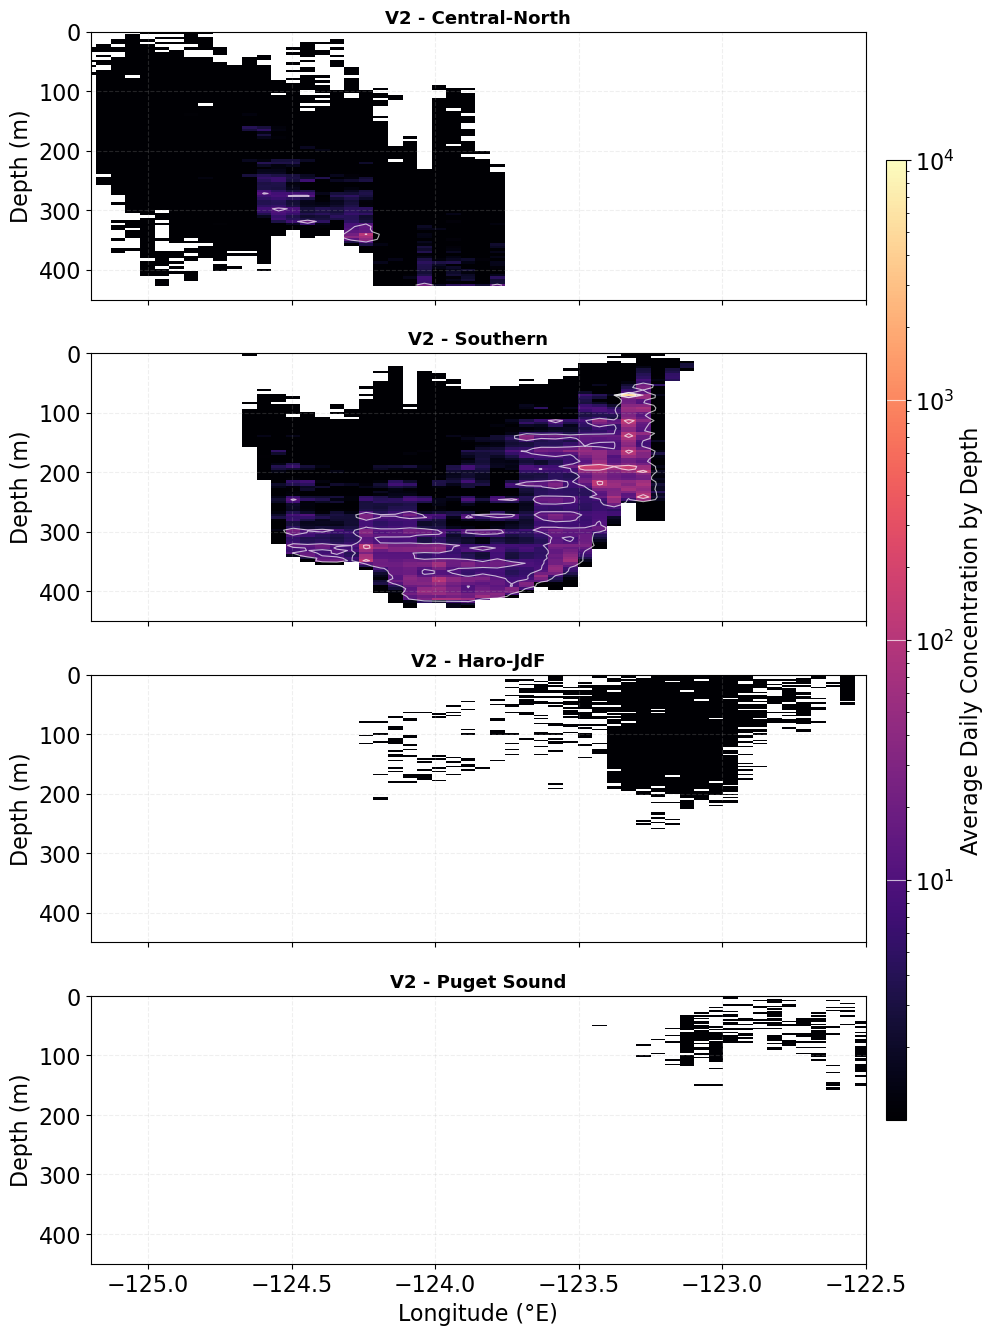

In [18]:
def clean_xy(x, y, z):
    x = x.flatten()
    y = y.flatten()
    z = z.flatten()
    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
    return x[mask], y[mask], z[mask]
#
with xr.open_dataset('/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Simulation_V2_year_1.nc').isel(obs=slice(2184, 2432)) as data_V2:
    # Clean only once
    lons_v2, lats_v2, z_v2 = clean_xy(data_V2['lon'].values, data_V2['lat'].values, data_V2['z'].values)

    slices = [slice_0, slice_1, slice_2, slice_3]
    slice_titles = ['Central-North', 'Southern', 'Haro-JdF', 'Puget Sound'] 
    df_list = []
    
    for s in slices:
        # Call the vectorized version directly
        df, _, _ = vertical_particles_sliced_vectorized(
            lons_v2, lats_v2, z_v2, mask=mask, jj_range=s
        )
        df_list.append(df)

    # 3. Determine Global Vmax for consistent colors
    valid_dfs = [df for df in df_list if df is not None]
    shared_norm = LogNorm(vmin=1, vmax=10000)
    levels = [10, 100, 1000, 10000]
    cmap_name = 'magma'

    # 4. Setup 2x2 Figure
    fig, axes = plt.subplots(4, 1, figsize=(10, 16), sharex=True, sharey=True)
    axes_flat = axes.flatten()

    for i, (df, ax) in enumerate(zip(df_list, axes_flat)):
        if df is None:
            ax.text(0.5, 0.5, "No Data in Slice", ha='center')
            continue

        X_centers = df.columns.values
        Y_centers = df.index.values
        Z_values = df.values / 365 # normalized by 365

        # Heatmap
        im = ax.pcolormesh(X_centers, Y_centers, Z_values, cmap=cmap_name, norm=shared_norm, shading='auto')
        
        # Contours
        lon_mesh, depth_mesh = np.meshgrid(X_centers, Y_centers)
        cs = ax.contour(lon_mesh, depth_mesh, Z_values, levels=levels, colors='white', linewidths=0.8, alpha=0.7)
        
        # Formatting
        ax.set_title(f'V2 - {slice_titles[i]}', fontsize=13, fontweight='bold')
        ax.set_ylim(450, 0) # Surface at 0 (top)
        ax.set_xlim(-125.2, -122.5)
        ax.grid(alpha=0.2, linestyle='--')

    # Shared Labels
    for ax in axes[:]: ax.set_ylabel('Depth (m)')
    ax.set_xlabel('Longitude (°E)')

    # 5. Shared Colorbar
    fig.subplots_adjust(right=0.9, hspace=0.2, wspace=0.1)
    cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
    cbar = fig.colorbar(im, cax=cbar_ax, ticks=levels)
    cbar.set_label('Average Daily Concentration by Depth')
    cbar.add_lines(cs)

    plt.show()

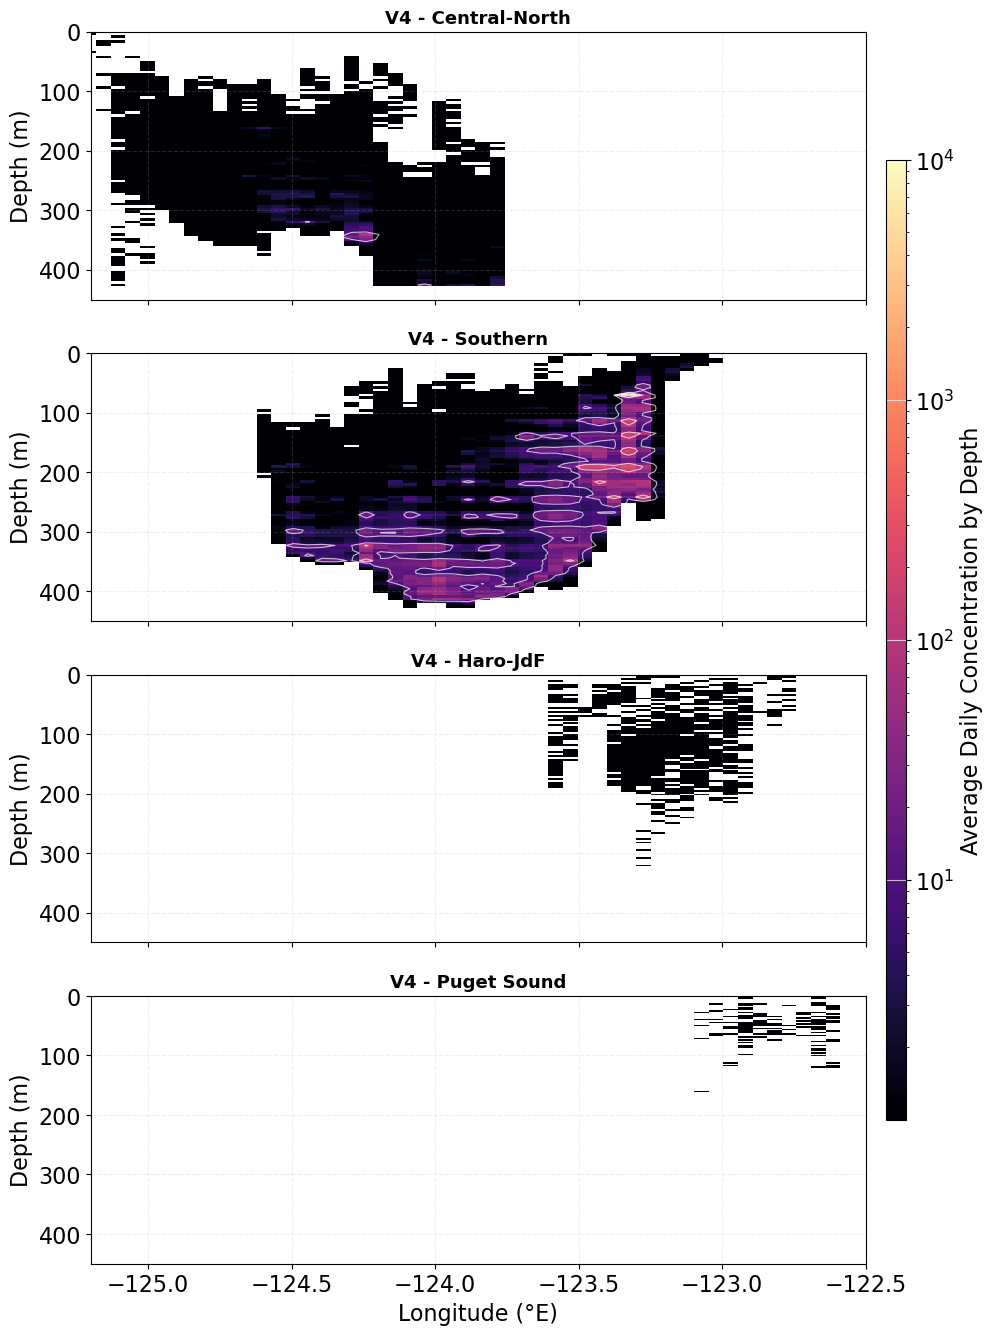

In [19]:
def clean_xy(x, y, z):
    x = x.flatten()
    y = y.flatten()
    z = z.flatten()
    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
    return x[mask], y[mask], z[mask]
#
with xr.open_dataset('/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Simulation_V4_year_1.nc').isel(obs=slice(2184, 2432)) as data_V4:
    # Clean only once
    lons_v4, lats_v4, z_v4 = clean_xy(data_V4['lon'].values, data_V4['lat'].values, data_V4['z'].values)

    slices = [slice_0, slice_1, slice_2, slice_3]
    slice_titles = ['Central-North', 'Southern', 'Haro-JdF', 'Puget Sound'] 
    df_list = []
    
    for s in slices:
        # Call the vectorized version directly
        df, _, _ = vertical_particles_sliced_vectorized(
            lons_v4, lats_v4, z_v4, mask=mask, jj_range=s
        )
        df_list.append(df)

    # 3. Determine Global Vmax for consistent colors
    valid_dfs = [df for df in df_list if df is not None]
    shared_norm = LogNorm(vmin=1, vmax=10000)
    levels = [10, 100, 1000, 10000]
    cmap_name = 'magma'

    # 4. Setup 2x2 Figure
    fig, axes = plt.subplots(4, 1, figsize=(10, 16), sharex=True, sharey=True)
    axes_flat = axes.flatten()

    for i, (df, ax) in enumerate(zip(df_list, axes_flat)):
        if df is None:
            ax.text(0.5, 0.5, "No Data in Slice", ha='center')
            continue

        X_centers = df.columns.values
        Y_centers = df.index.values
        Z_values = df.values / 365

        # Heatmap
        im = ax.pcolormesh(X_centers, Y_centers, Z_values, cmap=cmap_name, norm=shared_norm, shading='auto')
        
        # Contours
        lon_mesh, depth_mesh = np.meshgrid(X_centers, Y_centers)
        cs = ax.contour(lon_mesh, depth_mesh, Z_values, levels=levels, colors='white', linewidths=0.8, alpha=0.7)
        
        # Formatting
        ax.set_title(f'V4 - {slice_titles[i]}', fontsize=13, fontweight='bold')
        ax.set_ylim(450, 0) # Surface at 0 (top)
        ax.set_xlim(-125.2, -122.5)
        ax.grid(alpha=0.2, linestyle='--')

    # Shared Labels
    for ax in axes[:]: ax.set_ylabel('Depth (m)')
    ax.set_xlabel('Longitude (°E)')

    # 5. Shared Colorbar
    fig.subplots_adjust(right=0.9, hspace=0.2, wspace=0.1)
    cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
    cbar = fig.colorbar(im, cax=cbar_ax, ticks=levels)
    cbar.set_label('Average Daily Concentration by Depth')
    cbar.add_lines(cs)

    plt.show()